In [5]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

In [2]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

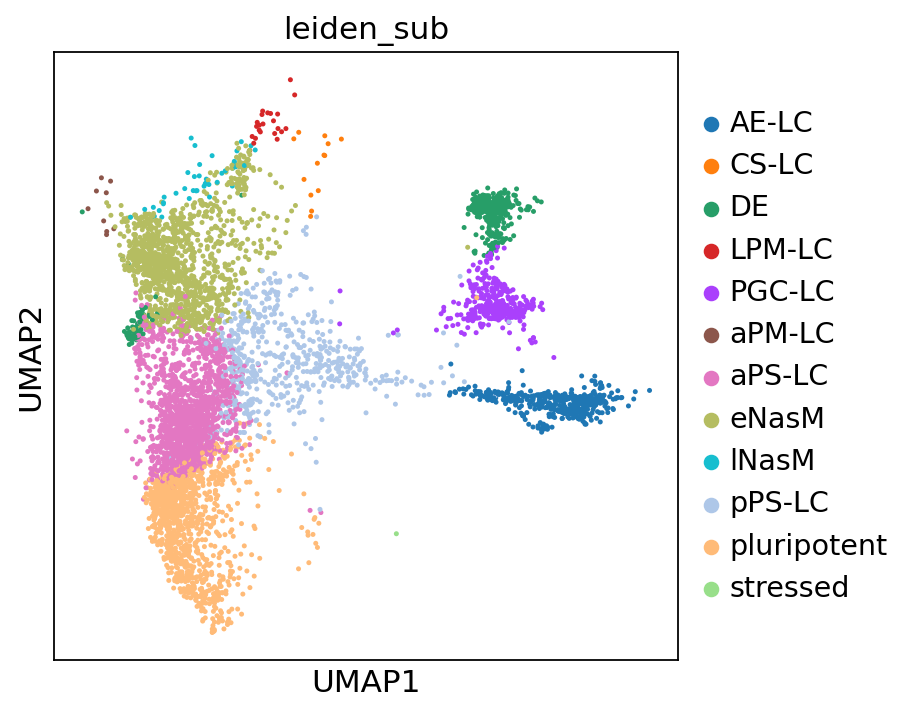

4611

In [3]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

07-01 08:37:27 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt
07-01 08:37:28 mp_print INFO 
Init min-dist clustering-tree
07-01 08:37:28 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
07-01 08:37:28 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
07-01 08:37:28 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

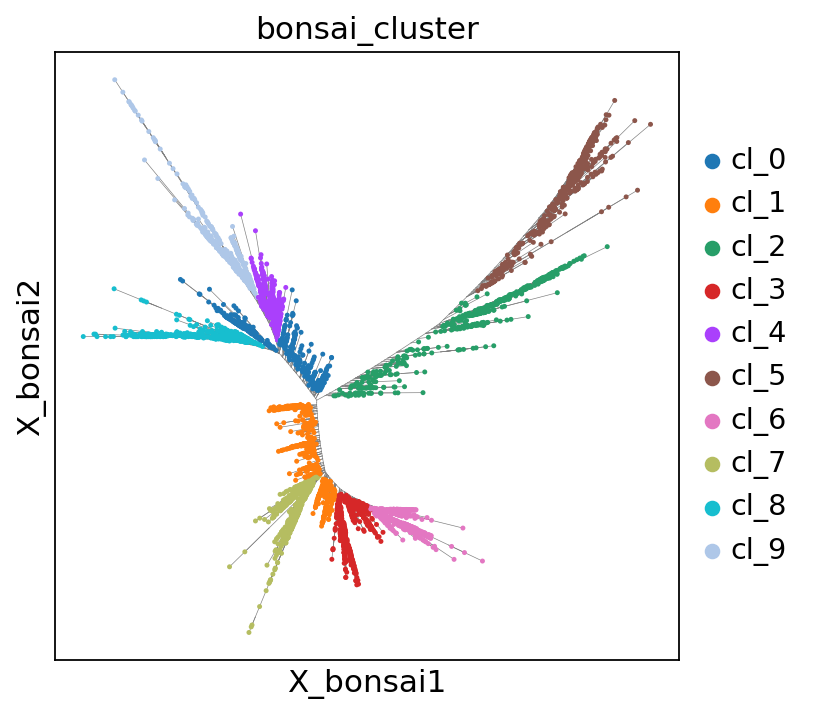

In [4]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
# reroot
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])
# clustering
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

In [ ]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)

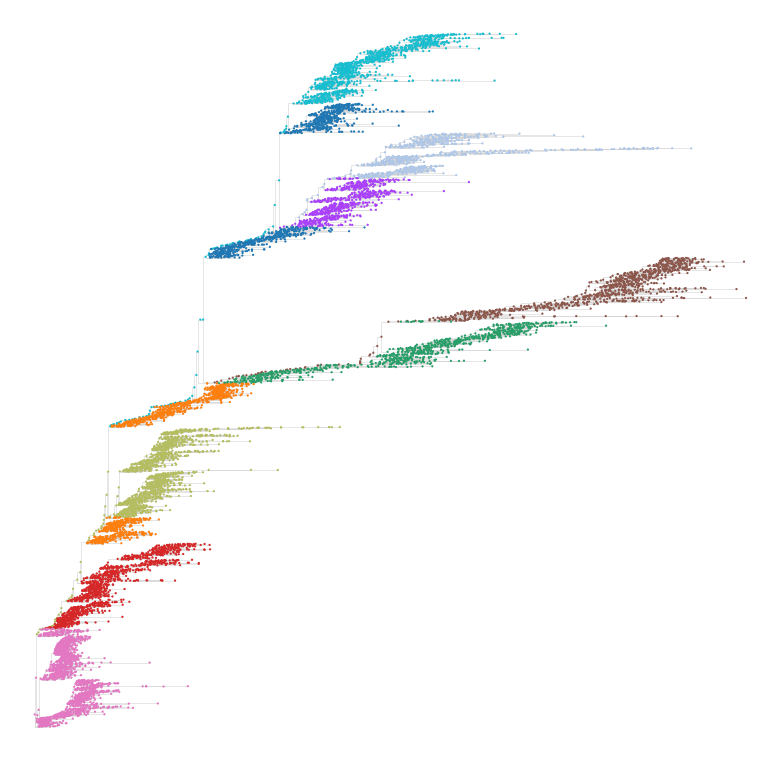

In [21]:
edge_df = scData.tree.get_edge_dataframe()
sources = edge_df["source"].to_list()
targets = edge_df["target"].to_list()

gas_edge_coords_d = np.zeros((len(sources), 3, 2))
for i, (s, t) in enumerate(zip(sources, targets)):
    gas_edge_coords_d[i, 0, :] = node_data_lookup[s].dendrogram_coords
    gas_edge_coords_d[i, 2, :] = node_data_lookup[t].dendrogram_coords
    gas_edge_coords_d[i, 1, 0] = node_data_lookup[s].dendrogram_coords[0]  # type: ignore[index]
    gas_edge_coords_d[i, 1, 1] = node_data_lookup[t].dendrogram_coords[1]  # type: ignore[index]

color_pal = dict(
    zip(adata.obs["bonsai_cluster"].cat.categories, adata.uns["bonsai_cluster_colors"])
)

cell_type_node_coords = []
cell_type_node_colors = []
for node_id, node_data in node_data_lookup.items():
    identity = node_data.identity
    if identity is None or node_id not in node_data_lookup:
        continue
    cell_type = max(identity, key=identity.get)
    cell_type_node_coords.append(node_data_lookup[node_id].dendrogram_coords)
    cell_type_node_colors.append(color_pal[cell_type])
cell_type_node_coords = np.array(cell_type_node_coords)


def plot_dendrogram_edges(ax):
    for e in gas_edge_coords_d:
        ax.plot(e[:, 0], e[:, 1], c="lightgray", lw=0.25, zorder=1)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.axis("off")


def get_score_coords_and_values(score_lookup):
    coords = []
    values = []
    for node_id, score in score_lookup.items():
        coords.append(node_data_lookup[node_id].dendrogram_coords)
        values.append(score)
    values = np.array(values, dtype=float)
    values[~np.isfinite(values)] = np.nan
    return np.array(coords), values


fig, ax = plt.subplots(figsize=(6, 6))
plot_dendrogram_edges(ax)
ax.scatter(
    cell_type_node_coords[:, 0],
    cell_type_node_coords[:, 1],
    c=cell_type_node_colors,
    s=1,
    lw=0,
    rasterized=True,
    zorder=2,
)

In [ ]:
# cl_9 are the potential DE cells that PGCs might converge to
reference_node_ids = adata.obs.index[adata.obs["bonsai_cluster"] == "cl_9"].to_list()
bl.convergence.compute_branch_projection(
    node_data_lookup=node_data_lookup,
    normalize_by_branch_length=True,
    gene_names=scData.metadata.geneIds,
    reference_node_ids=reference_node_ids,
)

compute branch projection for 11068 branches × 382 refs
normalize branch projection by branch length


/home/stan/Git/bonsai-loop/src/bonsai_loop/convergence.py:757: RuntimeWarning: divide by zero encountered in divide
  diff_xz = X - Z[i]
/home/stan/Git/bonsai-loop/src/bonsai_loop/convergence.py:757: RuntimeWarning: invalid value encountered in divide
  diff_xz = X - Z[i]
/home/stan/Git/bonsai-loop/src/bonsai_loop/convergence.py:755: RuntimeWarning: invalid value encountered in divide
  


In [37]:
# root node
print(node_data_lookup["internal_1880"])
# root has no parent so no branch projection
print(node_data_lookup["internal_1880"].branch_projection)

┌────────────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                          │ value                                        │
├────────────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                          │ TreeNode(nodeId='internal_1880')             │
│ topological_level                  │ 195                                          │
│ geometric_level                    │ None                                         │
│ identity                           │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                           │ 5927                                         │
│ ordering_value                     │ None                                         │
│ dendrogram_coords                  │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent        │ None                                         │
│ delta_deviation_from_parent_smooth │ None           

In [ ]:
# a internal node
print(node_data_lookup["internal_720"])
node_data_lookup["internal_720"].branch_projection.iloc[:10, :10]

┌────────────────────────────────────┬─────────────────────────────────────────────┐
│ attribute                          │ value                                       │
├────────────────────────────────────┼─────────────────────────────────────────────┤
│ tree_node                          │ TreeNode(nodeId='internal_720')             │
│ topological_level                  │ 1                                           │
│ geometric_level                    │ None                                        │
│ identity                           │ [(cl_7,1.0)]                                │
│ n_leaves                           │ 2                                           │
│ ordering_value                     │ None                                        │
│ dendrogram_coords                  │ (-0.6702649058685906, -0.22972494093823825) │
│ delta_deviation_from_parent        │ None                                        │
│ delta_deviation_from_parent_smooth │ None                      

,AASS,ABCA7,ABCG2,ABHD12B,ABRACL,ACAT2,ACSL4,ACTA1,ACTB,ACTC1
AAAGTGACAACGATCT-1_48h,-0.000794,0.000271,0.002608,0.000102,-0.000972,-0.001065,0.001026,-0.001743,-0.002063,-0.000294
AAAGTGATCACCATCC-1_48h,-0.000944,0.000383,0.002628,0.000073,-0.000302,-0.002832,0.000475,-0.001759,0.001398,-0.000231
AACAACCCAAGTCCCG-1_48h,-0.000823,0.000143,0.002939,0.000054,-0.001096,-0.001317,0.000304,-0.001877,-0.001213,-0.000535
AACACACTCACCTACC-1_48h,-0.000518,0.000115,0.002990,0.000293,-0.000881,-0.002051,0.000443,-0.001928,-0.007862,-0.000417
AACAGGGTCATAGGCT-1_48h,-0.000981,0.000346,0.002651,0.000073,-0.000908,-0.001966,0.000845,-0.001772,0.000235,-0.000303
AACCACAAGCTAAGTA-1_48h,-0.000290,0.000021,0.000871,0.000196,-0.000795,-0.001195,-0.000911,-0.000768,0.000390,0.001197
AACCCAATCACCACAA-1_48h,-0.001322,-0.000066,0.002806,0.000241,-0.001287,-0.004828,0.001012,-0.001900,-0.002342,0.000439
AACCTGATCGCCAGTG-1_48h,-0.000849,0.000135,0.002581,0.000122,-0.001368,0.000164,0.001288,-0.001725,-0.003468,-0.000257
AACCTTTGTTTCGCTC-1_48h,-0.000780,-0.000023,0.002292,0.000238,-0.001432,-0.002039,0.001114,-0.001643,-0.001237,0.000694
AACTTCTCATCCGGTG-1_48h,-0.000520,0.000003,0.002583,0.000210,-0.001461,0.000452,0.000473,-0.001727,-0.003518,-0.000222


In [40]:
# a real cell (a leaf)
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"])
node_data_lookup["AAACGAATCTGCAGCG-1_48h"].branch_projection.iloc[:10, :10]

┌────────────────────────────────────┬────────────────────────────────────────────┐
│ attribute                          │ value                                      │
├────────────────────────────────────┼────────────────────────────────────────────┤
│ tree_node                          │ TreeNode(nodeId='AAACGAATCTGCAGCG-1_48h')  │
│ topological_level                  │ 0                                          │
│ geometric_level                    │ None                                       │
│ identity                           │ [(cl_2,1.0)]                               │
│ n_leaves                           │ 1                                          │
│ ordering_value                     │ None                                       │
│ dendrogram_coords                  │ (0.09773739395356817, 0.09009449881876486) │
│ delta_deviation_from_parent        │ None                                       │
│ delta_deviation_from_parent_smooth │ None                                 

,AASS,ABCA7,ABCG2,ABHD12B,ABRACL,ACAT2,ACSL4,ACTA1,ACTB,ACTC1
AAAGTGACAACGATCT-1_48h,0.000127,0.000062,0.000720,-0.000093,-0.000549,0.000235,-0.000009,0.000048,-0.000238,0.000342
AAAGTGATCACCATCC-1_48h,0.000059,-0.000032,0.000707,-0.000110,-0.001330,0.000734,0.000004,0.000047,-0.000799,0.000285
AACAACCCAAGTCCCG-1_48h,0.000166,0.000199,0.000762,-0.000133,-0.000577,0.000281,0.000009,0.000047,-0.000425,0.000514
AACACACTCACCTACC-1_48h,0.000549,0.000400,0.001368,0.000004,-0.001484,0.000851,0.000011,0.000085,0.001065,0.000754
AACAGGGTCATAGGCT-1_48h,0.000046,0.000002,0.000716,-0.000111,-0.000642,0.000488,-0.000005,0.000047,-0.000618,0.000344
AACCACAAGCTAAGTA-1_48h,0.000294,0.000260,0.000265,0.000016,-0.000333,0.000403,0.000043,0.000016,-0.000639,-0.001199
AACCCAATCACCACAA-1_48h,-0.000094,0.000427,0.000863,-0.000023,-0.000356,0.001487,-0.000008,0.000058,-0.000269,-0.000263
AACCTGATCGCCAGTG-1_48h,0.000096,0.000183,0.000741,-0.000081,-0.000052,-0.000129,-0.000016,0.000049,0.000005,0.000322
AACCTTTGTTTCGCTC-1_48h,0.000117,0.000362,0.000762,0.000002,0.000149,0.000640,-0.000015,0.000055,-0.000405,-0.000554
AACTTCTCATCCGGTG-1_48h,0.000299,0.000345,0.000834,-0.000029,0.000055,-0.000245,0.000004,0.000055,0.000009,0.000331


In [105]:
# aggregate branch projection among cl_1, which is where convergence is happening
# use the identity to do a little filtering
identity_threshold = 0.5
cl_1_nodes = []
for node_id, node_data in node_data_lookup.items():
    if node_data.identity is None:
        continue
    for ct, prob in node_data.identity.items():
        if ct == "cl_1":
            if prob > identity_threshold:
                cl_1_nodes.append(node_id)
                break
print(f"{len(cl_1_nodes)} nodes in cl_1")
pprint(cl_1_nodes[:10])

1072 nodes in cl_1
['internal_1',
 'TCAAGTGTCTGTCAGA-1_48h',
 'ACTCCCACAAGCGGAT-1_48h',
 'internal_3',
 'internal_4',
 'internal_8',
 'internal_10',
 'internal_73',
 'internal_85',
 'internal_86']


In [106]:
aggregated_branch_projection = None
for node_id in cl_1_nodes:
    if aggregated_branch_projection is None:
        aggregated_branch_projection = np.array(
            node_data_lookup[node_id]
            .branch_projection.replace(np.inf, 0)
            .replace(-np.inf, 0)
            .mean(axis=0, skipna=True)
            .fillna(0)
        )
    else:
        if node_data_lookup[node_id].branch_projection is not None:
            aggregated_branch_projection += np.array(
                node_data_lookup[node_id]
                .branch_projection.replace(np.inf, 0)
                .replace(-np.inf, 0)
                .replace(np.inf, 0)
                .mean(axis=0, skipna=True)
                .fillna(0)
            )

In [109]:
aggregated_branch_projection[np.array(scData.metadata.geneIds) == "PRDM1"]

array([0.14474088])

In [108]:
np.array(scData.metadata.geneIds)[np.argsort(-aggregated_branch_projection)][:60]

array(['SOX17', 'EDNRB', 'ENC1', 'APOBEC3G', 'S1PR3', 'GDF3', 'FEZ1',
       'GATA6', 'MOBP', 'RHOBTB3', 'KCNV1', 'NEFM', 'FREM1', 'FAM184A',
       'HPDL', 'ITGA5', 'SOX2', 'PRDM1', 'LHX1', 'KCNH5', 'CYP2S1',
       'BMP2', 'ABHD12B', 'VASH2', 'IFI16', 'PCDH17', 'APOA2', 'TRIML2',
       'TBX3', 'FOXB1', 'ARHGAP24', 'CBR3', 'ARID5B', 'DIO3', 'LZTS1',
       'MKRN1', 'LIFR', 'PDGFA', 'MANEA', 'AHNAK', 'PPP2R2B', 'C9orf135',
       'ACTA1', 'TMEM158', 'GLIPR1L1', 'SPATA16', 'ABCG2', 'GAP43',
       'PIM2', 'GPR160', 'PLAAT3', 'GLIPR2', 'LEFTY2', 'APELA', 'RFPL2',
       'ADAMTS18', 'SAMD11', 'CDH7', 'LBH', 'BHLHE22'], dtype='<U11')

# We need better filtering of branches
- filter by bonsai clusters
- filter by cell types
- filter by delta deviation